In [51]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM

import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

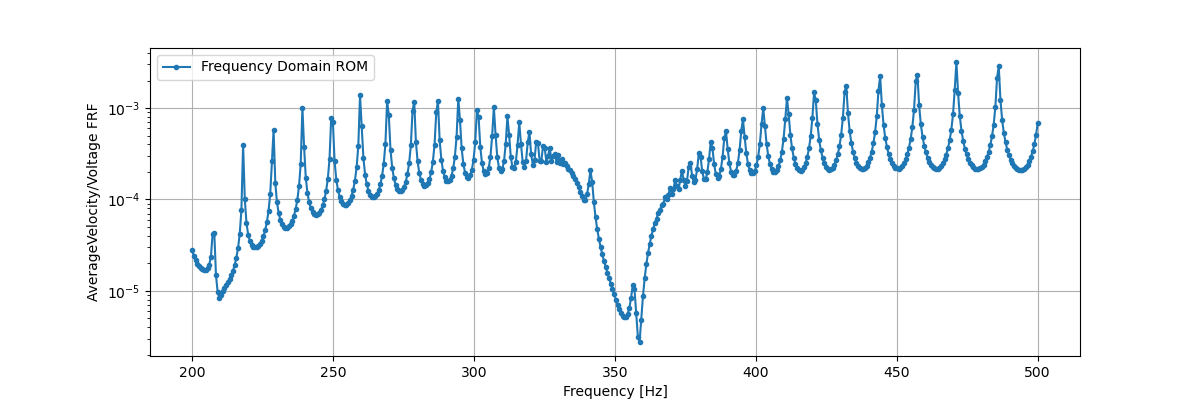

In [52]:
%matplotlib widget

Q = 300
params = PiezoBeamParams( 
    Q = Q, L_b=3.185
    )
params.zeta_p = 0.0151/100
params.zeta_q = 0.0392/100
N = 80
rom = ROM(params, N=N)


#%%
x_eval = np.linspace(0, rom.p.L_b, 500)

K_i = 60; K_p = 1e-4; K_c = 0

f0 = 200; f1 = 500

j_exc = 299
freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
										w=np.linspace(f0, f1, 500)*2*np.pi, x_eval=x_eval)
# %matplotlib widget
plt.figure(figsize=(12, 4))
# plt.semilogy(frq_linear_exp, np.mean(frf_data_linear_exp[:,:], axis=1), 'r--', label=' Experiment')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w']*2*pi*comsol_OC['freq'], 'g-', label='COMSOL ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC_exp, np.mean(frf_data_SC_exp[:,:], axis=1), 'b--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
# plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM'   )
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Experiment')
# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')

# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )
plt.legend()
# plt.xlim([1300, 3000])
# plt.xlim([f0, f1])
# plt.ylim([1e-5, 1e-3])
# plt.ylim([3e-5, 6e-4])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()


In [53]:

rom.omega/(2*pi)

array([5.69543113e-02, 3.56926576e-01, 9.99404749e-01, 1.95843443e+00,
       3.23743244e+00, 4.83616348e+00, 6.75464161e+00, 8.99286605e+00,
       1.15508368e+01, 1.44285540e+01, 1.76260175e+01, 2.11432273e+01,
       2.49801835e+01, 2.91368860e+01, 3.36133349e+01, 3.84095301e+01,
       4.35254717e+01, 4.89611596e+01, 5.47165939e+01, 6.07917745e+01,
       6.71867015e+01, 7.39013748e+01, 8.09357944e+01, 8.82899604e+01,
       9.59638728e+01, 1.03957532e+02, 1.12270937e+02, 1.20904088e+02,
       1.29856986e+02, 1.39129630e+02, 1.48722020e+02, 1.58634157e+02,
       1.68866040e+02, 1.79417670e+02, 1.90289046e+02, 2.01480168e+02,
       2.12991036e+02, 2.24821651e+02, 2.36972012e+02, 2.49442120e+02,
       2.62231974e+02, 2.75341574e+02, 2.88770921e+02, 3.02520014e+02,
       3.16588853e+02, 3.30977439e+02, 3.45685771e+02, 3.60713849e+02,
       3.76061674e+02, 3.91729245e+02, 4.07716562e+02, 4.24023626e+02,
       4.40650436e+02, 4.57596993e+02, 4.74863296e+02, 4.92449345e+02,
      

c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\ProgramData\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


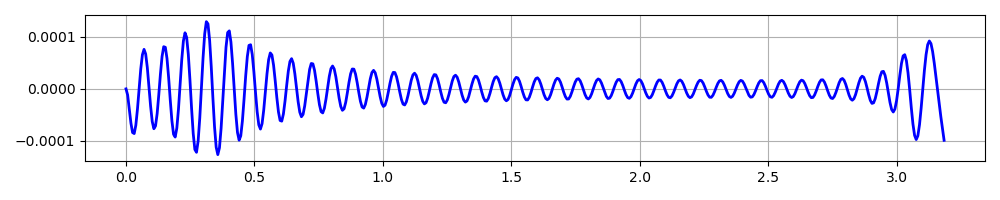

In [54]:

# =================== Mode shape at single frequency ===================
single_freq = np.array([341])
  # Hz - choose your frequency of interest
single_w = single_freq * 2 * np.pi
x_eval_mode = np.linspace(0, rom.p.L_b, 500)

# Get frequency response at single frequency
freq_single, vel_mag_single, disp_mag_single, veloc_frq = rom.frequency_response(
    K_c=K_c, K_p=K_p, K_i=K_i, w=single_w, x_eval=x_eval_mode
)

# veloc_frq has shape (n_spatial_points, 1) - extract the mode shape

# Plot the mode shape
plt.figure(figsize=(10, 2))
plt.plot(x_eval_mode,  veloc_frq[:, 0], 'b-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Velocity magnitude [m/s]')
# plt.title(f'Mode shape at {single_freq} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
# %%
# print("ki0= ", ki0, 'beta= ', beta, 'f_target= ', single_freq)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 61 concurrent workers.


Running simulations in parallel...


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed:   49.3s remaining:  2.1min
[Parallel(n_jobs=-1)]: Done   3 out of   7 | elapsed:   52.3s remaining:  1.2min
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:   54.5s remaining:   40.8s
[Parallel(n_jobs=-1)]: Done   5 out of   7 | elapsed:   55.0s remaining:   21.9s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:   57.3s finished


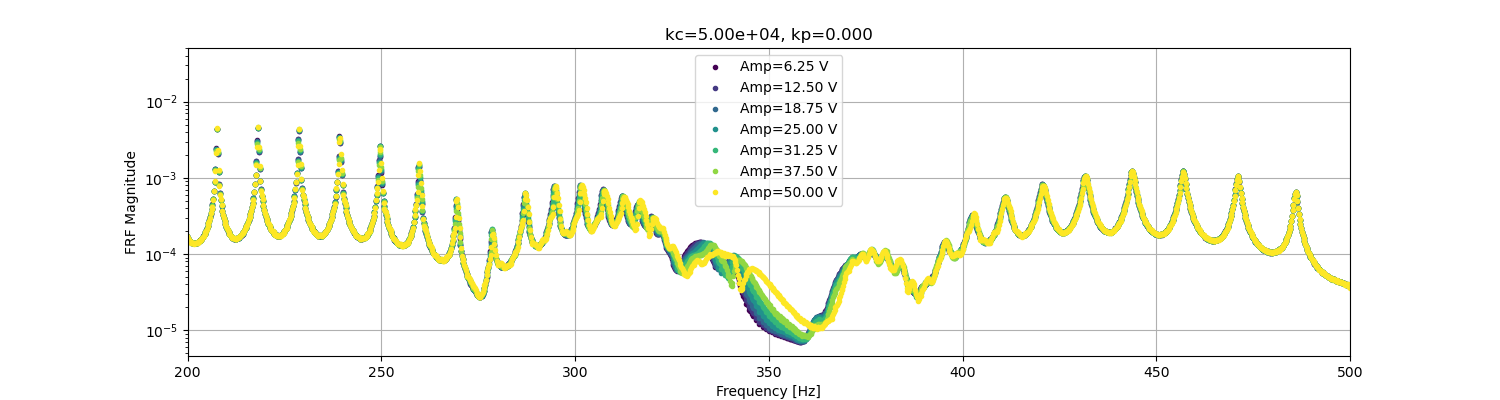

In [55]:
# ======= Function to run single simulation =======
K_c = 5e4
K_p = 2e-4
t_end = 5
t_eval = np.arange(0, t_end, 1/f1/20)
param_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]) * 125 # Amplitude sweep
def run_single_simulation(par, K_c, K_p, K_i, t_end, f0, f1, x_eval, t_eval):
	"""Run a single simulation for given amplitude parameter"""
	print(f"Amp = {par} ...")	

	def v_exc(t, A_exc=par, f0=f0, f1=f1, t_end=t_end):
		return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
	
	res = rom.run_time_sim(v_exc=v_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
	
	return {
		"param": par,
		"t": res['t'],
		"veloc": res['veloc'],
		"freq": res['freq'],
		"Y": res['Y'],
		"X": res['X'],
		"FRF": res['FRF']
	}

# ======= Run simulations in parallel =======

print("Running simulations in parallel...")
sim_results = Parallel(n_jobs=-1, verbose=10)(
	delayed(run_single_simulation)(par, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, f0=f0, f1=f1, x_eval=x_eval, t_eval=t_eval) 
	for par in param_list
)

# ======= Collect results =======
results = {
	"params": [],
	"param_name": "Amp",
	"t": None,
	"veloc": [],
	"freq": None,
	"Y": [],
	"X": [],
	"FRF": []
}

for i, res in enumerate(sim_results):
	results["params"].append(res["param"])
	results["veloc"].append(res["veloc"])
	results["Y"].append(res["Y"])
	results["FRF"].append(res["FRF"])
	results["X"].append(res["X"])
	
	# Save time and frequency (from first simulation)
	if results["freq"] is None:
		results["freq"] = res["freq"]
		results["t"] = res["t"]

#%%
# np.savez('./'+f"sim_dat/amp_sweep_Kc={K_c:.2e}_Kp={K_p:.3f}_Ki={K_i:.0f}"+'.npz', **results)


plt.figure(figsize=(15,4))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(results['params'])))   # gradient from low A → high A
i = -1
for A, FRF in zip(results["params"], results["FRF"]):
	i +=1
	# plt.semilogy(results["freq"], FRF, linewidth=1.2, label=f"A={A:.2f} V")
	plt.semilogy(results["freq"], FRF, '.',color=colors[i], linewidth=3, label=f"{results['param_name']}={A:.2f} V")

plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF Magnitude")
plt.title(f"kc={K_c:.2e}, kp={K_p:0.3f}")
# plt.xlim([1300, 3000])
plt.xlim([f0, f1])
# plt.ylim([3e-5, 6e-4])
plt.grid(True)
plt.legend()
plt.show()


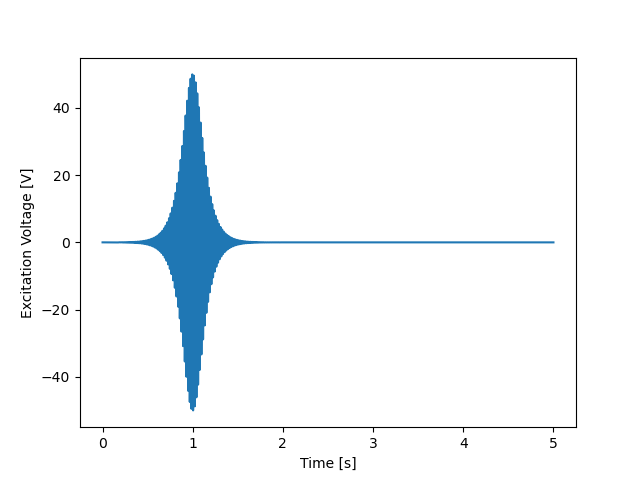

In [56]:

# def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
# 	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)

def v_exc(t, A_exc=50, f_exc=341/(2*np.pi), t_end=t_end, tau=0.1):
	t0 = t_end / 5
	envelope = 1 / np.cosh((t - t0) / tau)
	return A_exc * envelope * np.cos(2*np.pi*f_exc*t)

plt.figure()
plt.plot(t_eval, v_exc(t_eval))
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.show()


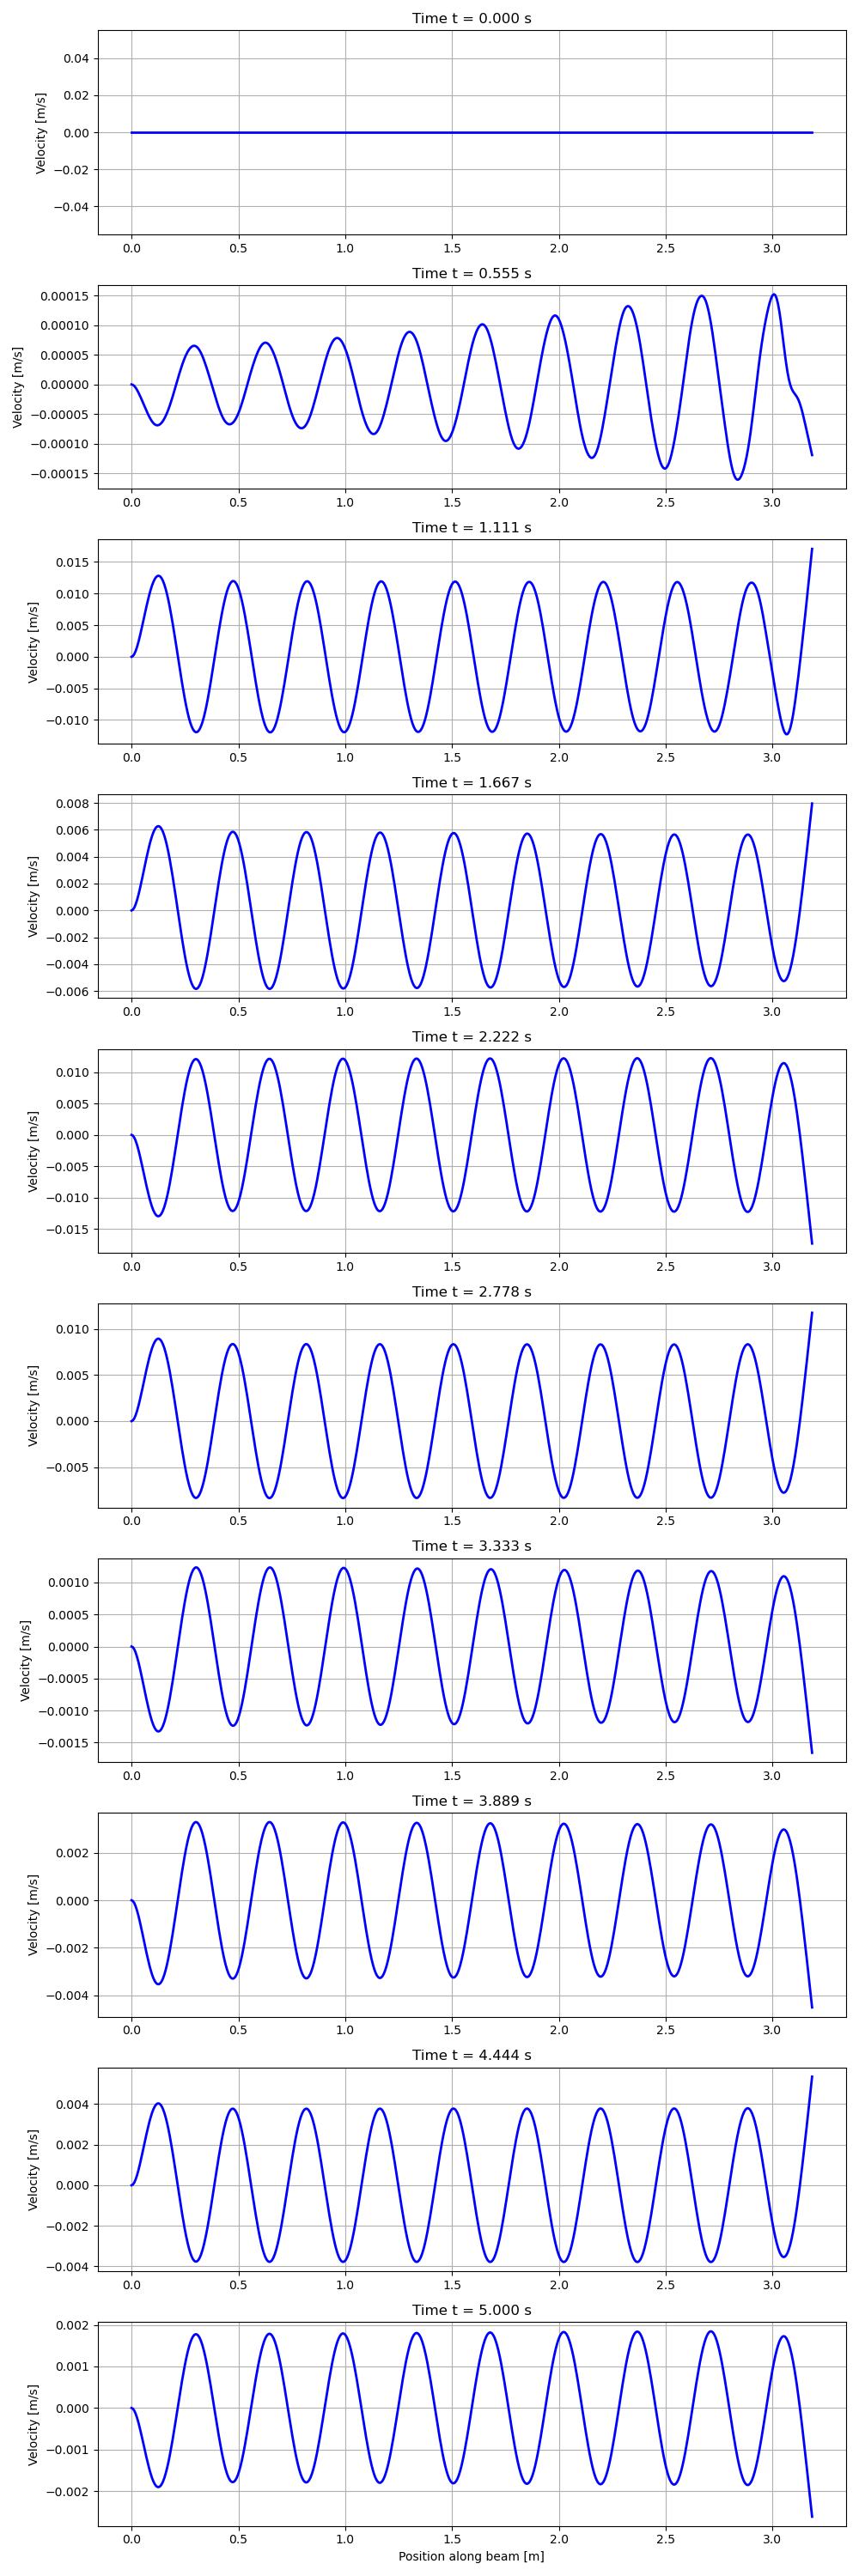

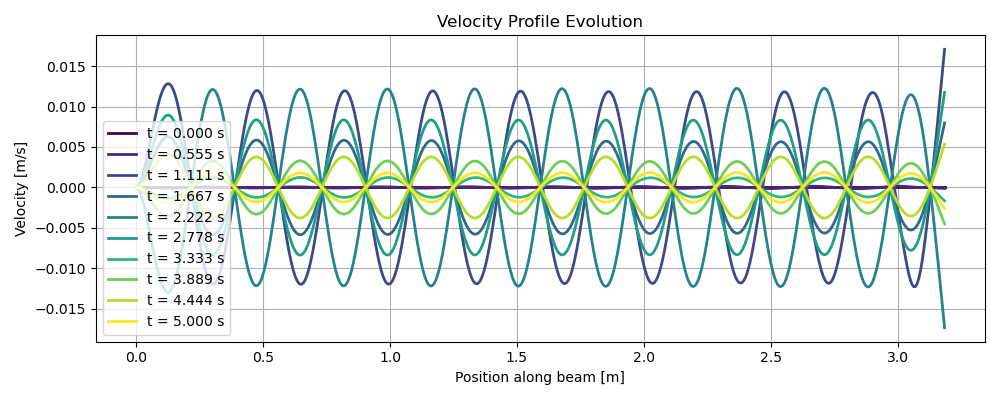

In [57]:

interface_idx = 4
beta = -0.3
# # ======= K_p sweep in frequency domain =======

# k0 = 4000
# kc2 = ki0 / (1 - beta)**2 
# kc1 = ki0 / (1 + beta)**2 
# S = rom.S
# K_i = np.zeros(S)
# K_i = np.zeros(S)
# for i in range(S):
# 	if i < interface_idx:
# 		K_i[i] = ki1 if i % 2 == 0 else ki2
# 	else:
# 		K_i[i] = ki2 if (i - interface_idx) % 2 == 0 else ki1

# print("K_i:", K_i, )
#%%
# x_eval = np.linspace(0, rom.p.L_b, 1000)
# x0 = np.zeros(2*N + 2*S)




results = rom.run_time_sim(v_exc=v_exc, j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

# freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
# 										w=np.linspace(f0, f1, 1000)*2*np.pi, x_eval=x_eval)
# =================== Velocity field at multiple time instances ===================
# Select a few time indices to visualize the spatial velocity profile evolution


n_times = len(t)
# Choose time instances: start, several intermediate times, and end
time_indices = np.linspace(0, n_times - 1, 10, dtype=int)
time_values = t[time_indices]

# Create subplots for each time instance
fig, axes = plt.subplots(len(time_indices), 1, figsize=(10, 3 * len(time_indices)))
if len(time_indices) == 1:
    axes = [axes]

for idx, (ax, t_idx) in enumerate(zip(axes, time_indices)):
    ax.plot(x_eval, veloc[:, t_idx], 'b-', linewidth=2)
    ax.set_ylabel('Velocity [m/s]')
    ax.set_title(f'Time t = {time_values[idx]:.3f} s')
    ax.grid(True)

axes[-1].set_xlabel('Position along beam [m]')
plt.tight_layout()
plt.show()

# Alternative: overlay all on same plot
plt.figure(figsize=(10, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for t_idx, color, t_val in zip(time_indices, colors, time_values):
    plt.plot(x_eval, veloc[:, t_idx], color=color, linewidth=2, label=f't = {t_val:.3f} s')
plt.xlabel('Position along beam [m]')
plt.ylabel('Velocity [m/s]')
plt.title('Velocity Profile Evolution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()